In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
data=pd.read_csv(r"D:\capstone_project\ml\capstone_python.csv")

In [11]:
data.isnull().any()

vehicle_uid          False
name                 False
year                 False
selling_price        False
km_driven            False
fuel                 False
seller_type          False
transmission         False
owner                False
car_record_id        False
car_age              False
price_category       False
km_category          False
owner_count          False
fuel_transmission    False
brand                False
price_per_km         False
is_diesel            False
dtype: bool

In [13]:
data

,vehicle_uid,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_record_id,car_age,price_category,km_category,owner_count,fuel_transmission,brand,price_per_km,is_diesel
0,CAR_000001,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,1,18,Low,Medium,0.0,Petrol_Manual,Maruti,0.86,0
1,CAR_000002,Maruti Wagon R LXI Minor,2007,135000.0,50000.0,Petrol,Individual,Manual,First Owner,2,18,Low,Medium,0.0,Petrol_Manual,Maruti,2.70,0
2,CAR_000003,Hyundai Verna 1.6 SX,2012,600000.0,100000.0,Diesel,Individual,Manual,First Owner,3,13,Low,Medium,0.0,Diesel_Manual,Hyundai,6.00,1
3,CAR_000004,Datsun RediGO T Option,2017,250000.0,46000.0,Petrol,Individual,Manual,First Owner,4,8,Low,Medium,0.0,Petrol_Manual,Datsun,5.43,0
4,CAR_000005,Honda Amaze VX i-DTEC,2014,450000.0,141000.0,Diesel,Individual,Manual,Second Owner,5,11,Low,High,0.0,Diesel_Manual,Honda,3.19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,CAR_004336,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999.0,60000.0,Diesel,Individual,Manual,Second Owner,4336,11,Mid,High,0.0,Diesel_Manual,Hyundai,5.12,1
4336,CAR_004337,Hyundai i20 Magna 1.4 CRDi,2014,409999.0,80000.0,Diesel,Individual,Manual,Second Owner,4337,11,Mid,High,0.0,Diesel_Manual,Hyundai,5.12,1
4337,CAR_004338,Maruti 800 AC BSIII,2009,110000.0,83000.0,Petrol,Individual,Manual,Second Owner,4338,16,Low,High,0.0,Petrol_Manual,Maruti,1.33,0
4338,CAR_004339,Hyundai Creta 1.6 CRDi SX Option,2016,865000.0,60000.0,Diesel,Individual,Manual,First Owner,4339,9,High,High,0.0,Diesel_Manual,Hyundai,9.61,1


In [30]:
data.drop(["vehicle_uid","name"],axis=1,inplace=True)

# Q1. Load the cleaned Car Evaluation dataset. Identify the Type of 
# ML Problem. Select 'price_category' as target variable, and print the shape of X and y.  

In [32]:
x=data.drop("price_category",axis=1)

In [34]:
y=data["price_category"]

In [37]:
print(x.shape)
print(y.shape)

(4340, 15)
(4340,)


# Q-2 Q2. Identify categorical columns, apply Encoding techniques (if 
# necessary), perform Standard Scaling on numerical features.   

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               4340 non-null   int64  
 1   selling_price      4340 non-null   float64
 2   km_driven          4340 non-null   float64
 3   fuel               4340 non-null   object 
 4   seller_type        4340 non-null   object 
 5   transmission       4340 non-null   object 
 6   owner              4340 non-null   object 
 7   car_record_id      4340 non-null   int64  
 8   car_age            4340 non-null   int64  
 9   price_category     4340 non-null   object 
 10  km_category        4340 non-null   object 
 11  owner_count        4340 non-null   float64
 12  fuel_transmission  4340 non-null   object 
 13  brand              4340 non-null   object 
 14  price_per_km       4340 non-null   float64
 15  is_diesel          4340 non-null   int64  
dtypes: float64(4), int64(4),

In [64]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [68]:
label=LabelEncoder()

In [70]:
label

LabelEncoder()

In [72]:
data.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'car_record_id', 'car_age', 'price_category',
       'km_category', 'owner_count', 'fuel_transmission', 'brand',
       'price_per_km', 'is_diesel'],
      dtype='object')

In [74]:
columns=["fuel", "seller_type",
       "transmission", "owner","price_category",
       "km_category", "fuel_transmission", "brand"]

In [76]:
for i in columns:
    data[i]=label.fit_transform(data[i])

In [78]:
data

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_record_id,car_age,price_category,km_category,owner_count,fuel_transmission,brand,price_per_km,is_diesel
0,2007,60000.0,70000.0,4,1,1,0,1,18,1,2,0.0,6,18,0.86,0
1,2007,135000.0,50000.0,4,1,1,0,2,18,1,2,0.0,6,18,2.70,0
2,2012,600000.0,100000.0,1,1,1,0,3,13,1,2,0.0,2,10,6.00,1
3,2017,250000.0,46000.0,4,1,1,0,4,8,1,2,0.0,6,5,5.43,0
4,2014,450000.0,141000.0,1,1,1,2,5,11,1,0,0.0,2,9,3.19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,2014,409999.0,60000.0,1,1,1,2,4336,11,2,0,0.0,2,10,5.12,1
4336,2014,409999.0,80000.0,1,1,1,2,4337,11,2,0,0.0,2,10,5.12,1
4337,2009,110000.0,83000.0,4,1,1,2,4338,16,1,0,0.0,6,18,1.33,0
4338,2016,865000.0,60000.0,1,1,1,0,4339,9,0,0,0.0,2,10,9.61,1


In [80]:
scale=StandardScaler()

In [82]:
scale

StandardScaler()

In [85]:
x=data.drop("price_category",axis=1)

In [87]:
y=data["price_category"]

In [91]:
scale.fit_transform(x)

array([[-1.44507431, -0.64241963,  0.09832559, ...,  0.35817253,
        -0.02292873, -0.99219635],
       [-1.44507431, -0.58524661, -0.34943325, ...,  0.35817253,
        -0.02244466, -0.99219635],
       [-0.2587948 , -0.23077383,  0.76996384, ..., -0.81667398,
        -0.02157648,  1.00786503],
       ...,
       [-0.97056251, -0.60430428,  0.38936883, ...,  0.35817253,
        -0.02280508, -0.99219635],
       [ 0.69022881, -0.02876247, -0.12555383, ..., -0.81667398,
        -0.02062675,  1.00786503],
       [ 0.69022881,  2.71249365, -0.57331267, ...,  1.0924516 ,
        -0.02167646, -0.99219635]])

# Q.3.Plot the distribution of car price categories. Analyse the relationship 
# between safety, selling price indicators, and number of owners or usage (km driven) with the target variable price category

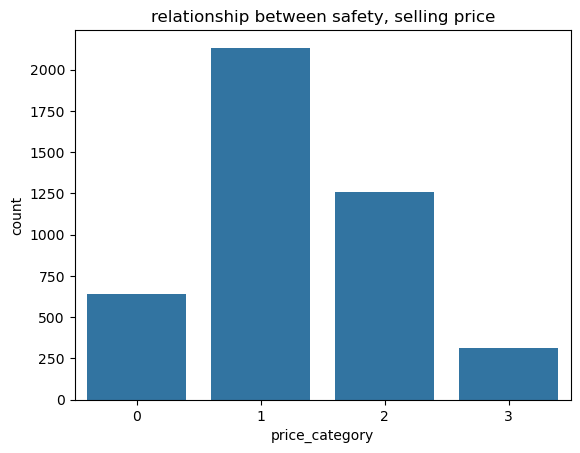

In [94]:
sns.countplot(x="price_category",data=data)
plt.title("relationship between safety, selling price")
plt.show()

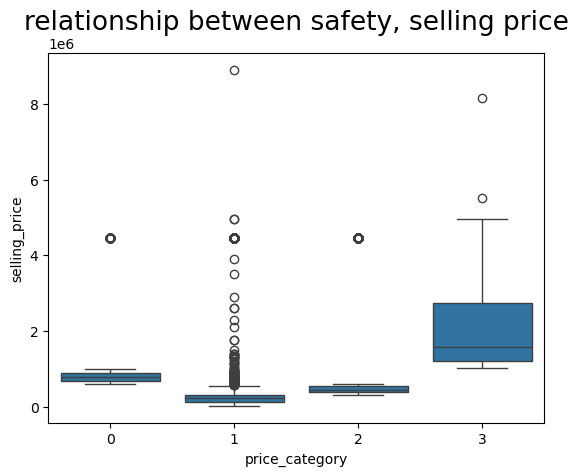

In [106]:
sns.boxplot(x="price_category",y="selling_price",data=data)
plt.title("relationship between safety, selling price",fontsize=19)
plt.show()

# Q.4 Split the dataset into training and testing sets. Train a SVM model 
# and display accuracy Score, Confusion Matrix, Classification report.  

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.svm import SVC

In [113]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [134]:
model=SVC(C=45,kernel="rbf")

In [136]:
model

SVC(C=45)

In [138]:
model.fit(x_train,y_train)

SVC(C=45)

In [140]:
model.score(x_train,y_train)*100

92.68433179723502

In [142]:
model.score(x_test,y_test)*100

48.15668202764977

In [144]:
ypri=model.predict(x_test)

In [151]:
accuracy_score(y_test,ypri)

0.4815668202764977

In [155]:
a=confusion_matrix(y_test,ypri)

<Axes: >

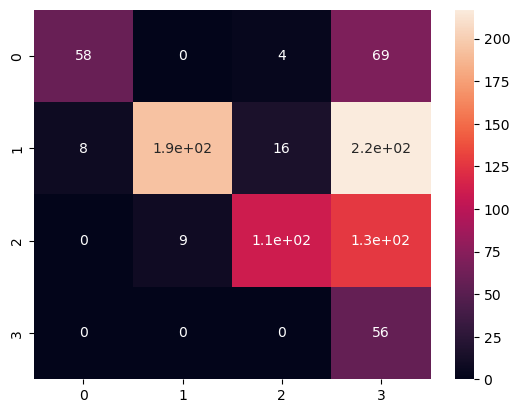

In [157]:
sns.heatmap(a,annot=True)

In [161]:
print(classification_report(y_test,ypri))

              precision    recall  f1-score   support

           0       0.88      0.44      0.59       131
           1       0.96      0.45      0.61       435
           2       0.85      0.45      0.59       246
           3       0.12      1.00      0.21        56

    accuracy                           0.48       868
   macro avg       0.70      0.58      0.50       868
weighted avg       0.86      0.48      0.57       868



# Q.5. Train a Random Forest Classifier on the same data and predict 
# price_category, find - accuracy Score, Confusion Matrix, Classification 
# report. Compare both models accuracy and print the best model for Prediction. 

In [186]:
from sklearn.ensemble import RandomForestClassifier

In [188]:
rc=RandomForestClassifier()

In [190]:
rc

RandomForestClassifier()

In [192]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [194]:
rc.fit(x_train,y_train)

RandomForestClassifier()

In [196]:
rc.score(x_train,y_train)*100

100.0

In [198]:
rc.score(x_test,y_test)*100

55.99078341013824

In [200]:
ypri_rc=model.predict(x_test)

In [202]:
accuracy_score(y_test,ypri_rc)

0.4815668202764977

In [204]:
confusion_matrix(y_test,ypri_rc)

array([[ 58,   0,   4,  69],
       [  8, 194,  16, 217],
       [  0,   9, 110, 127],
       [  0,   0,   0,  56]], dtype=int64)

In [206]:
print(classification_report(y_test,ypri_rc))

              precision    recall  f1-score   support

           0       0.88      0.44      0.59       131
           1       0.96      0.45      0.61       435
           2       0.85      0.45      0.59       246
           3       0.12      1.00      0.21        56

    accuracy                           0.48       868
   macro avg       0.70      0.58      0.50       868
weighted avg       0.86      0.48      0.57       868



In [210]:
pwd

'C:\\Users\\HP\\fingertips\\mock_test'

In [212]:
cd D:\capstone_project\ml

D:\capstone_project\ml


In [208]:
data.to_csv("capstone_ml.csv",index=False)